In [1]:
import datetime
import enum
import json
import logging
import random
import re
import string
import pandas as pd
from websocket import create_connection
import requests
import json

logger = logging.getLogger(__name__)


class Interval(enum.Enum):
    in_1_minute = "1"
    in_3_minute = "3"
    in_5_minute = "5"
    in_15_minute = "15"
    in_30_minute = "30"
    in_45_minute = "45"
    in_1_hour = "1H"
    in_2_hour = "2H"
    in_3_hour = "3H"
    in_4_hour = "4H"
    in_daily = "1D"
    in_weekly = "1W"
    in_monthly = "1M"


class TvDatafeed:
    __sign_in_url = 'https://www.tradingview.com/accounts/signin/'
    __search_url = 'https://symbol-search.tradingview.com/symbol_search/?text={}&hl=1&exchange={}&lang=en&type=&domain=production'
    __ws_headers = json.dumps({"Origin": "https://data.tradingview.com"})
    __signin_headers = {'Referer': 'https://www.tradingview.com'}
    __ws_timeout = 5

    def __init__(self, username, password, timeout=30):
        self.username = username
        self.password = password
        self.timeout = timeout


    def __init__(
        self,
        username: str = None,
        password: str = None,
    ) -> None:
        """Create TvDatafeed object

        Args:
            username (str, optional): tradingview username. Defaults to None.
            password (str, optional): tradingview password. Defaults to None.
        """

        self.ws_debug = False

        self.token = self.__auth(username, password)

        if self.token is None:
            self.token = "unauthorized_user_token"
            logger.warning(
                "you are using nologin method, data you access may be limited"
            )

        self.ws = None
        self.session = self.__generate_session()
        self.chart_session = self.__generate_chart_session()

    def __auth(self, username, password):

        if (username is None or password is None):
            token = None

        else:
            data = {"username": username,
                    "password": password,
                    "remember": "on"}
            try:
                response = requests.post(
                    url=self.__sign_in_url, data=data, headers=self.__signin_headers)
                token = response.json()['user']['auth_token']
            except Exception as e:
                logger.error('error while signin')
                token = None

        return token

    def __create_connection(self):
        logging.debug("creating websocket connection")
        self.ws = create_connection(
            "wss://data.tradingview.com/socket.io/websocket", headers=self.__ws_headers, timeout=self.__ws_timeout
        )

    @staticmethod
    def __filter_raw_message(text):
        try:
            found = re.search('"m":"(.+?)",', text).group(1)
            found2 = re.search('"p":(.+?"}"])}', text).group(1)

            return found, found2
        except AttributeError:
            logger.error("error in filter_raw_message")

    @staticmethod
    def __generate_session():
        stringLength = 12
        letters = string.ascii_lowercase
        random_string = "".join(random.choice(letters)
                                for i in range(stringLength))
        return "qs_" + random_string

    @staticmethod
    def __generate_chart_session():
        stringLength = 12
        letters = string.ascii_lowercase
        random_string = "".join(random.choice(letters)
                                for i in range(stringLength))
        return "cs_" + random_string

    @staticmethod
    def __prepend_header(st):
        return "~m~" + str(len(st)) + "~m~" + st

    @staticmethod
    def __construct_message(func, param_list):
        return json.dumps({"m": func, "p": param_list}, separators=(",", ":"))

    def __create_message(self, func, paramList):
        return self.__prepend_header(self.__construct_message(func, paramList))

    def __send_message(self, func, args):
        m = self.__create_message(func, args)
        if self.ws_debug:
            print(m)
        self.ws.send(m)

    @staticmethod
    def __create_df(raw_data, symbol):
        try:
            out = re.search('"s":\[(.+?)\}\]', raw_data).group(1)
            x = out.split(',{"')
            data = list()
            volume_data = True

            for xi in x:
                xi = re.split("\[|:|,|\]", xi)
                ts = datetime.datetime.fromtimestamp(float(xi[4]))

                row = [ts]

                for i in range(5, 10):

                    # skip converting volume data if does not exists
                    if not volume_data and i == 9:
                        row.append(0.0)
                        continue
                    try:
                        row.append(float(xi[i]))

                    except ValueError:
                        volume_data = False
                        row.append(0.0)
                        logger.debug('no volume data')

                data.append(row)

            data = pd.DataFrame(
                data, columns=["datetime", "open",
                               "high", "low", "close", "volume"]
            ).set_index("datetime")
            data.insert(0, "symbol", value=symbol)
            return data
        except AttributeError:
            logger.error("no data, please check the exchange and symbol")

    @staticmethod
    def __format_symbol(symbol, exchange, contract: int = None):

        if ":" in symbol:
            pass
        elif contract is None:
            symbol = f"{exchange}:{symbol}"

        elif isinstance(contract, int):
            symbol = f"{exchange}:{symbol}{contract}!"

        else:
            raise ValueError("not a valid contract")

        return symbol

    def get_hist(
        self,
        symbol: str,
        exchange: str = "NSE",
        interval: Interval = Interval.in_daily,
        n_bars: int = 10,
        fut_contract: int = None,
        extended_session: bool = False,
    ) -> pd.DataFrame:
        """get historical data

        Args:
            symbol (str): symbol name
            exchange (str, optional): exchange, not required if symbol is in format EXCHANGE:SYMBOL. Defaults to None.
            interval (str, optional): chart interval. Defaults to 'D'.
            n_bars (int, optional): no of bars to download, max 5000. Defaults to 10.
            fut_contract (int, optional): None for cash, 1 for continuous current contract in front, 2 for continuous next contract in front . Defaults to None.
            extended_session (bool, optional): regular session if False, extended session if True, Defaults to False.

        Returns:
            pd.Dataframe: dataframe with sohlcv as columns
        """
        symbol = self.__format_symbol(
            symbol=symbol, exchange=exchange, contract=fut_contract
        )

        interval = interval.value

        self.__create_connection()

        self.__send_message("set_auth_token", [self.token])
        self.__send_message("chart_create_session", [self.chart_session, ""])
        self.__send_message("quote_create_session", [self.session])
        self.__send_message(
            "quote_set_fields",
            [
                self.session,
                "ch",
                "chp",
                "current_session",
                "description",
                "local_description",
                "language",
                "exchange",
                "fractional",
                "is_tradable",
                "lp",
                "lp_time",
                "minmov",
                "minmove2",
                "original_name",
                "pricescale",
                "pro_name",
                "short_name",
                "type",
                "update_mode",
                "volume",
                "currency_code",
                "rchp",
                "rtc",
            ],
        )

        self.__send_message(
            "quote_add_symbols", [self.session, symbol,
                                  {"flags": ["force_permission"]}]
        )
        self.__send_message("quote_fast_symbols", [self.session, symbol])

        self.__send_message(
            "resolve_symbol",
            [
                self.chart_session,
                "symbol_1",
                '={"symbol":"'
                + symbol
                + '","adjustment":"splits","session":'
                + ('"regular"' if not extended_session else '"extended"')
                + "}",
            ],
        )
        self.__send_message(
            "create_series",
            [self.chart_session, "s1", "s1", "symbol_1", interval, n_bars],
        )
        self.__send_message("switch_timezone", [
                            self.chart_session, "exchange"])

        raw_data = ""

        logger.debug(f"getting data for {symbol}...")
        while True:
            try:
                result = self.ws.recv()
                raw_data = raw_data + result + "\n"
            except Exception as e:
                logger.error(e)
                break

            if "series_completed" in result:
                break

        return self.__create_df(raw_data, symbol)

    def search_symbol(self, text: str, exchange: str = ''):
        url = self.__search_url.format(text, exchange)

        symbols_list = []
        try:
            resp = requests.get(url)

            symbols_list = json.loads(resp.text.replace(
                '</em>', '').replace('<em>', ''))
        except Exception as e:
            logger.error(e)

        return symbols_list

## Sample Test Code
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    print(tv.get_hist("CRUDEOIL", "MCX", fut_contract=1))
    print(tv.get_hist("NIFTY", "NSE", fut_contract=1))
    print(
        tv.get_hist(
            "EICHERMOT",
            "NSE",
            interval=Interval.in_1_hour,
            n_bars=500,
            extended_session=False,
        )
    )

In [2]:
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_weekly, n_bars=10000))
    print(df)

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): www.tradingview.com:443
DEBUG:urllib3.connectionpool:https://www.tradingview.com:443 "POST /accounts/signin/ HTTP/1.1" 200 None
DEBUG:root:creating websocket connection
DEBUG:__main__:getting data for INDEX:BTCUSD...


                           symbol          open          high           low  \
datetime                                                                      
2009-10-05 08:00:00  INDEX:BTCUSD      0.000764      0.001200      0.000764   
2009-10-12 08:00:00  INDEX:BTCUSD      0.001102      0.001245      0.001102   
2009-10-19 08:00:00  INDEX:BTCUSD      0.001248      0.001288      0.001211   
2009-10-26 08:00:00  INDEX:BTCUSD      0.001266      0.001285      0.001219   
2009-11-02 08:00:00  INDEX:BTCUSD      0.001256      0.001306      0.001256   
...                           ...           ...           ...           ...   
2023-03-20 08:00:00  INDEX:BTCUSD  28068.320000  28919.300000  26670.820000   
2023-03-27 08:00:00  INDEX:BTCUSD  27995.810000  29182.100000  26527.130000   
2023-04-03 08:00:00  INDEX:BTCUSD  28187.210000  28786.040000  27231.580000   
2023-04-10 08:00:00  INDEX:BTCUSD  28343.160000  31046.250000  28175.970000   
2023-04-17 08:00:00  INDEX:BTCUSD  30324.120000  304

df.to_csv("btc_data.csv")
saving the dataframe

In [3]:
df["buy_close_sell_open_weekly_profit"] = df["close"] - df["open"]
df = df.reset_index()
print(df.columns)
df.head(10)

Index(['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'buy_close_sell_open_weekly_profit'],
      dtype='object')


,datetime,symbol,open,high,low,close,volume,buy_close_sell_open_weekly_profit
0,2009-10-05 08:00:00,INDEX:BTCUSD,0.000764,0.001200,0.000764,0.001153,0.0,0.000389
1,2009-10-12 08:00:00,INDEX:BTCUSD,0.001102,0.001245,0.001102,0.001225,0.0,0.000123
2,2009-10-19 08:00:00,INDEX:BTCUSD,0.001248,0.001288,0.001211,0.001288,0.0,0.000040
3,2009-10-26 08:00:00,INDEX:BTCUSD,0.001266,0.001285,0.001219,0.001219,0.0,-0.000047
4,2009-11-02 08:00:00,INDEX:BTCUSD,0.001256,0.001306,0.001256,0.001260,0.0,0.000004
5,2009-11-09 08:00:00,INDEX:BTCUSD,0.001260,0.001355,0.001236,0.001236,0.0,-0.000025
6,2009-11-16 08:00:00,INDEX:BTCUSD,0.001189,0.001189,0.001059,0.001059,0.0,-0.000130
7,2009-11-23 08:00:00,INDEX:BTCUSD,0.001000,0.001000,0.000829,0.000829,0.0,-0.000171
8,2009-11-30 08:00:00,INDEX:BTCUSD,0.000824,0.000824,0.000733,0.000733,0.0,-0.000091
9,2009-12-07 08:00:00,INDEX:BTCUSD,0.000718,0.000718,0.000618,0.000618,0.0,-0.000100


DEBUG:matplotlib:matplotlib data path: C:\Users\Harvey\anaconda3\lib\site-packages\matplotlib\mpl-data
DEBUG:matplotlib:CONFIGDIR=C:\Users\Harvey\.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is win32
DEBUG:matplotlib:loaded modules: ['sys', 'builtins', '_frozen_importlib', '_imp', '_thread', '_warnings', '_weakref', '_io', 'marshal', 'nt', 'winreg', '_frozen_importlib_external', 'time', 'zipimport', '_codecs', 'codecs', 'encodings.aliases', 'encodings', 'encodings.utf_8', 'encodings.cp1252', '_signal', 'encodings.latin_1', '_abc', 'abc', 'io', '__main__', '_stat', 'stat', '_collections_abc', 'genericpath', 'ntpath', 'os.path', 'os', '_sitebuiltins', '_locale', '_bootlocale', '_distutils_hack', 'types', 'importlib._bootstrap', 'importlib._bootstrap_external', 'warnings', 'importlib', 'importlib.machinery', '_heapq', 'heapq', 'itertools', 'keyword', '_operator', 'operator', 'reprlib', '_collections', 'collections', 'collections.abc', '_functools', 'functool

When you buy the weekly close and sell the weekly open, your total profit so far will be $28166.709528599997


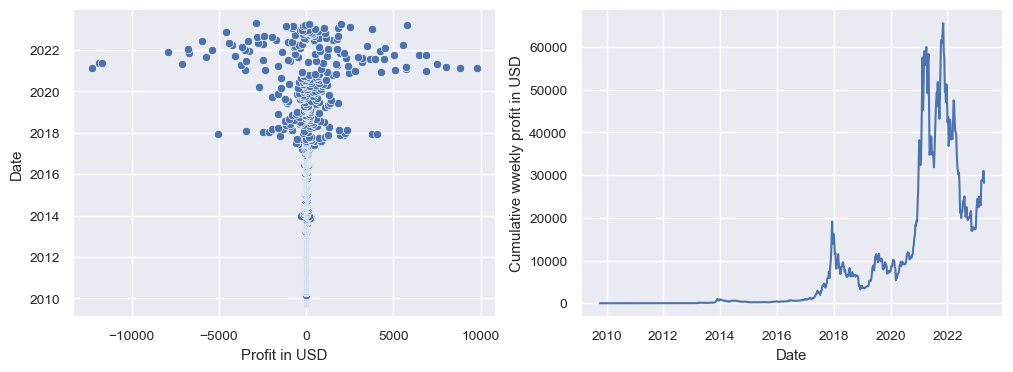

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
logging.getLogger('matplotlib.font_manager').disabled = True
###Above is the code to disable the font manager logger showing long lines of font error
sns.set(font_scale=0.9, font="Arial")
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%d %H:%M:%S")
###converting date string to datetime object
cumulative_profit = df["buy_close_sell_open_weekly_profit"].cumsum()

total_profit = df["buy_close_sell_open_weekly_profit"].sum()
# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# First subplot - scatter plot
sns.scatterplot(data=df, x="buy_close_sell_open_weekly_profit", y="datetime", ax=ax1)
ax1.set_xlabel("Profit in USD")
ax1.set_ylabel("Date")

# Second subplot - line plot
sns.lineplot(data=df, x="datetime", y=cumulative_profit, ax=ax2)
ax2.set_xlabel("Date")
ax2.set_ylabel("Cumulative wwekly profit in USD")

print(f"When you buy the weekly close and sell the weekly open, your total profit so far will be ${total_profit}")
# Show the plot
plt.show()

In [5]:
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_monthly, n_bars=10000))

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): www.tradingview.com:443
DEBUG:urllib3.connectionpool:https://www.tradingview.com:443 "POST /accounts/signin/ HTTP/1.1" 200 None
DEBUG:root:creating websocket connection
DEBUG:__main__:getting data for INDEX:BTCUSD...


In [6]:
df["buy_close_sell_open_monthly_profit"] = df["close"] - df["open"]
df = df.reset_index()
print(df.columns)
df.head(10)

Index(['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'buy_close_sell_open_monthly_profit'],
      dtype='object')


,datetime,symbol,open,high,low,close,volume,buy_close_sell_open_monthly_profit
0,2009-10-01 08:00:00,INDEX:BTCUSD,0.000764,0.001288,0.000764,0.001247,0.00,0.000483
1,2009-11-01 08:00:00,INDEX:BTCUSD,0.001219,0.001355,0.000824,0.000824,0.00,-0.000395
2,2009-12-01 08:00:00,INDEX:BTCUSD,0.000811,0.000811,0.000613,0.000689,0.00,-0.000122
3,2010-01-01 08:00:00,INDEX:BTCUSD,0.000718,0.003366,0.000718,0.003298,0.00,0.002580
4,2010-02-01 08:00:00,INDEX:BTCUSD,0.003297,0.005298,0.003297,0.005298,0.00,0.002001
5,2010-03-01 08:00:00,INDEX:BTCUSD,0.005397,0.005472,0.005397,0.005472,0.00,0.000075
6,2010-04-01 08:00:00,INDEX:BTCUSD,0.003000,0.003000,0.003000,0.003000,0.00,0.000000
7,2010-05-01 08:00:00,INDEX:BTCUSD,0.003000,0.004900,0.003000,0.004500,0.00,0.001500
8,2010-06-01 08:00:00,INDEX:BTCUSD,0.004600,0.005800,0.004400,0.005400,0.00,0.000800
9,2010-07-01 08:00:00,INDEX:BTCUSD,0.005500,0.093070,0.005500,0.067850,31858.88,0.062350


When you buy the monthly close and sell the monthly open, your total profit so far will be $27462.255972239993


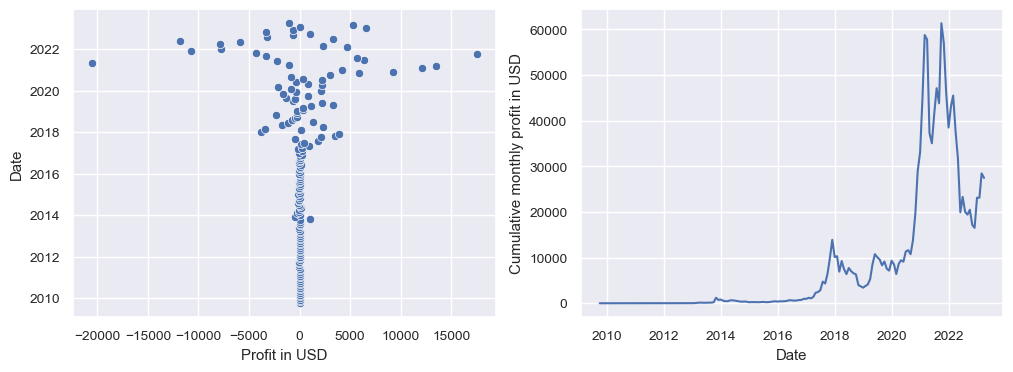

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
logging.getLogger('matplotlib.font_manager').disabled = True
###Above is the code to disable the font manager logger showing long lines of font error
sns.set(font_scale=0.9, font="Arial")
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%d %H:%M:%S")
###converting date string to datetime object
cumulative_profit = df["buy_close_sell_open_monthly_profit"].cumsum()

total_profit = df["buy_close_sell_open_monthly_profit"].sum()
# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# First subplot - scatter plot
sns.scatterplot(data=df, x="buy_close_sell_open_monthly_profit", y="datetime", ax=ax1)
ax1.set_xlabel("Profit in USD")
ax1.set_ylabel("Date")

# Second subplot - line plot
sns.lineplot(data=df, x="datetime", y=cumulative_profit, ax=ax2)
ax2.set_xlabel("Date")
ax2.set_ylabel("Cumulative monthly profit in USD")

print(f"When you buy the monthly close and sell the monthly open, your total profit so far will be ${total_profit}")
# Show the plot
plt.show()

In [8]:
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_daily, n_bars=10000))

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): www.tradingview.com:443
DEBUG:urllib3.connectionpool:https://www.tradingview.com:443 "POST /accounts/signin/ HTTP/1.1" 200 None
DEBUG:root:creating websocket connection
DEBUG:__main__:getting data for INDEX:BTCUSD...


In [9]:
df["buy_close_sell_open_daily_profit"] = df["close"] - df["open"]
df = df.reset_index()
print(df.columns)
df.head(10)

Index(['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'buy_close_sell_open_daily_profit'],
      dtype='object')


,datetime,symbol,open,high,low,close,volume,buy_close_sell_open_daily_profit
0,2009-10-05 08:00:00,INDEX:BTCUSD,0.000764,0.000764,0.000764,0.000764,0.0,0.0
1,2009-10-06 08:00:00,INDEX:BTCUSD,0.000885,0.000885,0.000885,0.000885,0.0,0.0
2,2009-10-07 08:00:00,INDEX:BTCUSD,0.001050,0.001050,0.001050,0.001050,0.0,0.0
3,2009-10-08 08:00:00,INDEX:BTCUSD,0.001084,0.001084,0.001084,0.001084,0.0,0.0
4,2009-10-09 08:00:00,INDEX:BTCUSD,0.001200,0.001200,0.001200,0.001200,0.0,0.0
5,2009-10-10 08:00:00,INDEX:BTCUSD,0.001120,0.001120,0.001120,0.001120,0.0,0.0
6,2009-10-11 08:00:00,INDEX:BTCUSD,0.001153,0.001153,0.001153,0.001153,0.0,0.0
7,2009-10-12 08:00:00,INDEX:BTCUSD,0.001102,0.001102,0.001102,0.001102,0.0,0.0
8,2009-10-13 08:00:00,INDEX:BTCUSD,0.001129,0.001129,0.001129,0.001129,0.0,0.0
9,2009-10-14 08:00:00,INDEX:BTCUSD,0.001136,0.001136,0.001136,0.001136,0.0,0.0


When you buy the daily close and sell the daily open, your total profit so far will be $28298.521710449946


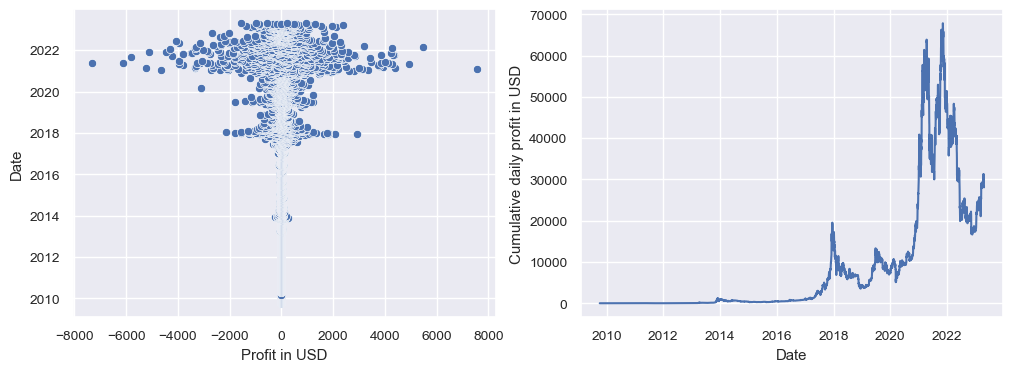

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
logging.getLogger('matplotlib.font_manager').disabled = True
###Above is the code to disable the font manager logger showing long lines of font error
sns.set(font_scale=0.9, font="Arial")
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%d %H:%M:%S")
###converting date string to datetime object
cumulative_profit = df["buy_close_sell_open_daily_profit"].cumsum()

total_profit = df["buy_close_sell_open_daily_profit"].sum()
# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# First subplot - scatter plot
sns.scatterplot(data=df, x="buy_close_sell_open_daily_profit", y="datetime", ax=ax1)
ax1.set_xlabel("Profit in USD")
ax1.set_ylabel("Date")

# Second subplot - line plot
sns.lineplot(data=df, x="datetime", y=cumulative_profit, ax=ax2)
ax2.set_xlabel("Date")
ax2.set_ylabel("Cumulative daily profit in USD")

print(f"When you buy the daily close and sell the daily open, your total profit so far will be ${total_profit}")
# Show the plot
plt.show()

In [11]:
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_4_hour, n_bars=5000))

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): www.tradingview.com:443
DEBUG:urllib3.connectionpool:https://www.tradingview.com:443 "POST /accounts/signin/ HTTP/1.1" 200 None
DEBUG:root:creating websocket connection
DEBUG:__main__:getting data for INDEX:BTCUSD...


In [12]:
df["buy_close_sell_open_4hour_profit"] = df["close"] - df["open"]
df = df.reset_index()
print(df.columns)
df.head(10)

Index(['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'buy_close_sell_open_4hour_profit'],
      dtype='object')


,datetime,symbol,open,high,low,close,volume,buy_close_sell_open_4hour_profit
0,2021-01-09 16:00:00,INDEX:BTCUSD,39671.8050,41267.4750,39336.3150,40628.0875,6445.272880,956.2825
1,2021-01-09 20:00:00,INDEX:BTCUSD,40640.4350,41415.1900,40296.4300,40632.2850,6927.508804,-8.1500
2,2021-01-10 00:00:00,INDEX:BTCUSD,40627.8200,40967.3725,39997.9525,40749.5275,6349.359957,121.7075
3,2021-01-10 04:00:00,INDEX:BTCUSD,40759.0250,40894.0525,40115.5125,40252.7450,6577.158262,-506.2800
4,2021-01-10 08:00:00,INDEX:BTCUSD,40249.6100,41452.4575,40248.5500,40485.6275,7387.612340,236.0175
5,2021-01-10 12:00:00,INDEX:BTCUSD,40473.0925,41176.9875,40177.9500,41057.1925,4704.092783,584.1000
6,2021-01-10 16:00:00,INDEX:BTCUSD,41074.3325,41143.2075,38975.6275,39233.0025,8696.242349,-1841.3300
7,2021-01-10 20:00:00,INDEX:BTCUSD,39227.1775,40174.0925,38570.7950,39725.2675,8462.990881,498.0900
8,2021-01-11 00:00:00,INDEX:BTCUSD,39726.1100,39795.5225,36812.1250,37384.7975,20773.343995,-2341.3125
9,2021-01-11 04:00:00,INDEX:BTCUSD,37389.2350,39064.3250,34624.0175,38173.3450,28361.094810,784.1100


When you buy the 4 hour close and sell the 4 hour open, your total profit so far will be $-12869.110000000112


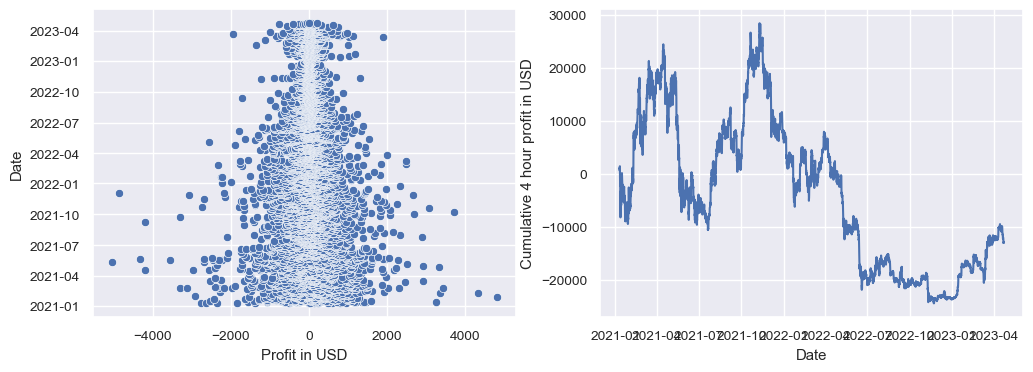

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
logging.getLogger('matplotlib.font_manager').disabled = True
###Above is the code to disable the font manager logger showing long lines of font error
sns.set(font_scale=0.9, font="Arial")
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%d %H:%M:%S")
###converting date string to datetime object
cumulative_profit = df["buy_close_sell_open_4hour_profit"].cumsum()

total_profit = df["buy_close_sell_open_4hour_profit"].sum()
# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# First subplot - scatter plot
sns.scatterplot(data=df, x="buy_close_sell_open_4hour_profit", y="datetime", ax=ax1)
ax1.set_xlabel("Profit in USD")
ax1.set_ylabel("Date")

# Second subplot - line plot
sns.lineplot(data=df, x="datetime", y=cumulative_profit, ax=ax2)
ax2.set_xlabel("Date")
ax2.set_ylabel("Cumulative 4 hour profit in USD")

print(f"When you buy the 4 hour close and sell the 4 hour open, your total profit so far will be ${total_profit}")
# Show the plot
plt.show()

## Volatility from price open analysis below

## For standard monthly volatility, but isn't what I need
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_monthly, n_bars=5000))
df['monthly_close_previous'] = df['close'].shift(1)
df['monthly_returns'] = (df['close'] / df['monthly_close_previous']) - 1
df['monthly_volatility'] = df['monthly_returns'].std()
df = df.reset_index()
print(df.columns)
df.tail(10)

In [20]:
import numpy as np
import pandas as pd
import logging
from datetime import datetime
from pytz import timezone
import seaborn as sns
import matplotlib.pyplot as plt
from tradingview_ta import TA_Handler, Interval, Exchange
from tradingview_ta.main import get_multiple_analysis

if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_weekly, n_bars=5000))
    

logging.basicConfig(level=logging.DEBUG)
# Reset the index
df = df.reset_index()
# Calculate the monthly returns and set the index to the datetime column
df['monthly_close_previous'] = df['close'].shift(1)
df['monthly_returns'] = (df['close'] / df['monthly_close_previous']) - 1
df.set_index('datetime', inplace=True)

# Calculate the rolling 12-month standard deviation of monthly returns
df['monthly_volatility'] = df['monthly_returns'].rolling(window=12).std() * np.sqrt(12)


# Print the columns to verify the new column is added
print(df.columns)

# Plot the monthly volatility
ax = sns.lineplot(data=df, x="datetime", y="monthly_volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Volatility")
plt.show()


DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): www.tradingview.com:443
DEBUG:urllib3.connectionpool:https://www.tradingview.com:443 "POST /accounts/signin/ HTTP/1.1" 200 None


AttributeError: type object 'Interval' has no attribute 'in_weekly'

In [19]:
df.head(10)

,symbol,open,high,low,close,volume,monthly_close_previous,monthly_returns,monthly_volatility
datetime,,,,,,,,,
2009-10-05 08:00:00,INDEX:BTCUSD,0.000764,0.001200,0.000764,0.001153,0.0,NaN,NaN,NaN
2009-10-12 08:00:00,INDEX:BTCUSD,0.001102,0.001245,0.001102,0.001225,0.0,0.001153,0.062495,NaN
2009-10-19 08:00:00,INDEX:BTCUSD,0.001248,0.001288,0.001211,0.001288,0.0,0.001225,0.051099,NaN
2009-10-26 08:00:00,INDEX:BTCUSD,0.001266,0.001285,0.001219,0.001219,0.0,0.001288,-0.053545,NaN
2009-11-02 08:00:00,INDEX:BTCUSD,0.001256,0.001306,0.001256,0.001260,0.0,0.001219,0.033935,NaN
2009-11-09 08:00:00,INDEX:BTCUSD,0.001260,0.001355,0.001236,0.001236,0.0,0.001260,-0.019612,NaN
2009-11-16 08:00:00,INDEX:BTCUSD,0.001189,0.001189,0.001059,0.001059,0.0,0.001236,-0.142859,NaN
2009-11-23 08:00:00,INDEX:BTCUSD,0.001000,0.001000,0.000829,0.000829,0.0,0.001059,-0.217103,NaN
2009-11-30 08:00:00,INDEX:BTCUSD,0.000824,0.000824,0.000733,0.000733,0.0,0.000829,-0.116272,NaN


In [ ]:
ax = sns.scatterplot(data=df, x="datetime", y="monthly_volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative 4 hour profit in USD")
ax

In [ ]:
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_weekly, n_bars=5000))
    df['weekly_close_previous'] = df['close'].shift(1)
df['weekly_returns'] = (df['close'] / df['close_previous']) - 1
df['weekly_monthly_volatility'] = df['returns'].std()
df = df.reset_index()
print(df.columns)
df.head(10)

In [ ]:
if __name__ == "__main__":
    logging.basicConfig(level=logging.DEBUG)
    tv = TvDatafeed("haharvs", "j2quantum*")
    df = pd.DataFrame(tv.get_hist(symbol='BTCUSD', exchange='INDEX', interval=Interval.in_daily, n_bars=5000))
df['daily_close_previous'] = df['close'].shift(1)
df['daily_returns'] = (df['close'] / df['close_previous']) - 1
df['daily_volatility'] = df['returns'].std()
df = df.reset_index()
print(df.columns)
df.head(10)